In [2]:
from mlxtend.plotting import plot_decision_regions
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

In [3]:
#Loading the dataset
diabetes_data = pd.read_csv('diabetes.csv')
#Print the first 5 rows of the dataframe.
diabetes_data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
diabetes_data.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [5]:
diabetes_data.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [6]:
diabetes_data.describe().T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


In [7]:
import numpy as np

# Make a deep copy
diabetes_data_copy = diabetes_data.copy(deep=True)

# Columns where 0 should be considered missing
cols_with_zeros = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

# Replace 0 with np.nan in these columns
diabetes_data_copy[cols_with_zeros] = diabetes_data_copy[cols_with_zeros].replace(0, np.nan)

# Show count of NaNs
print(diabetes_data_copy.isnull().sum())


Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64


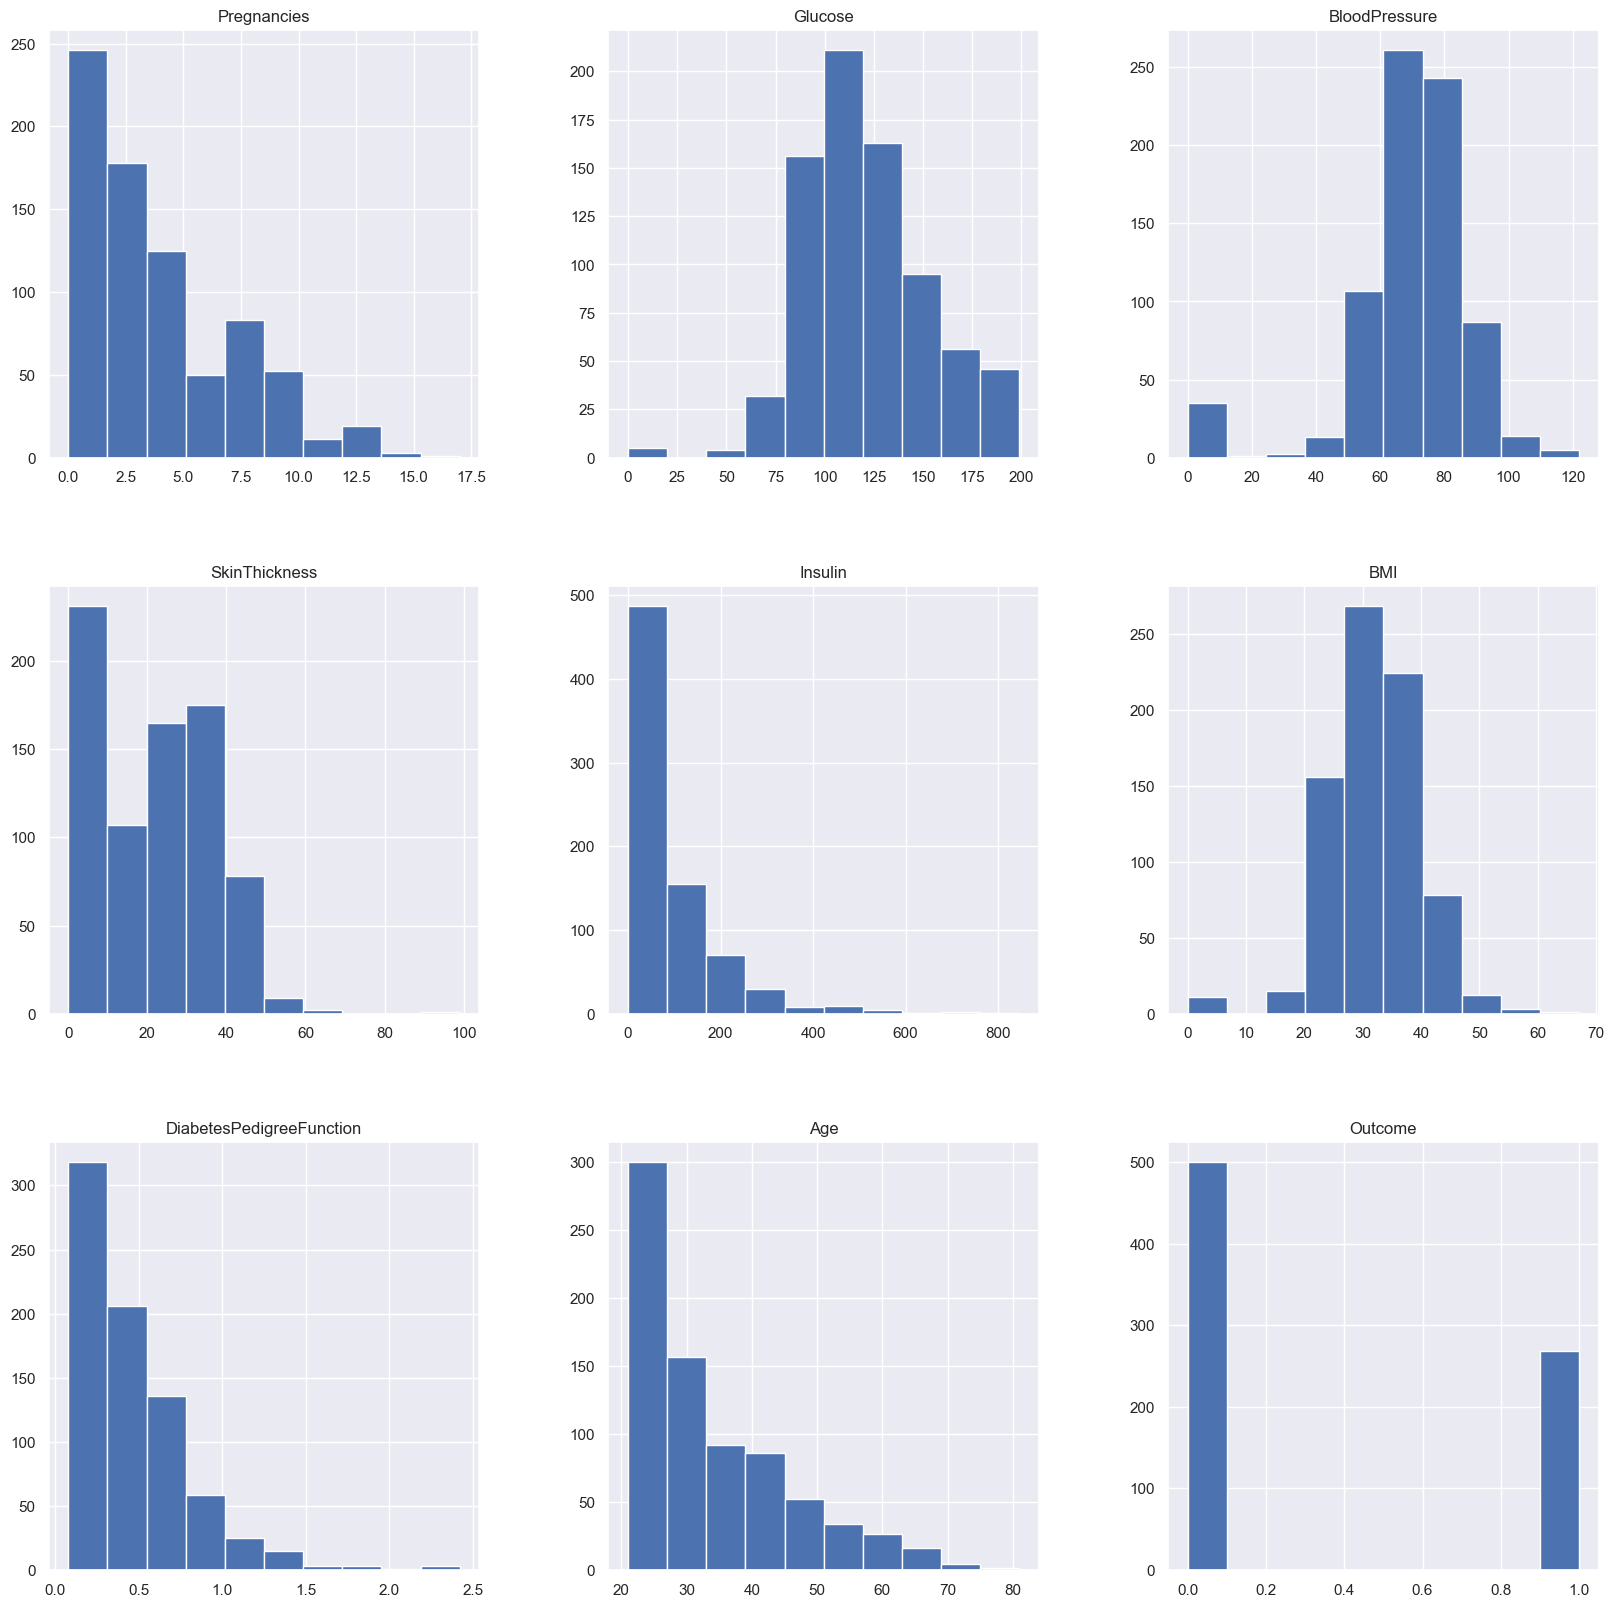

In [8]:
p = diabetes_data.hist(figsize = (20,20))

In [9]:
# Fill missing values in the dataset
diabetes_data_copy['Glucose'].fillna(diabetes_data_copy['Glucose'].mean(), inplace=True)
diabetes_data_copy['BloodPressure'].fillna(diabetes_data_copy['BloodPressure'].mean(), inplace=True)
diabetes_data_copy['SkinThickness'].fillna(diabetes_data_copy['SkinThickness'].median(), inplace=True)
diabetes_data_copy['Insulin'].fillna(diabetes_data_copy['Insulin'].median(), inplace=True)
diabetes_data_copy['BMI'].fillna(diabetes_data_copy['BMI'].median(), inplace=True)

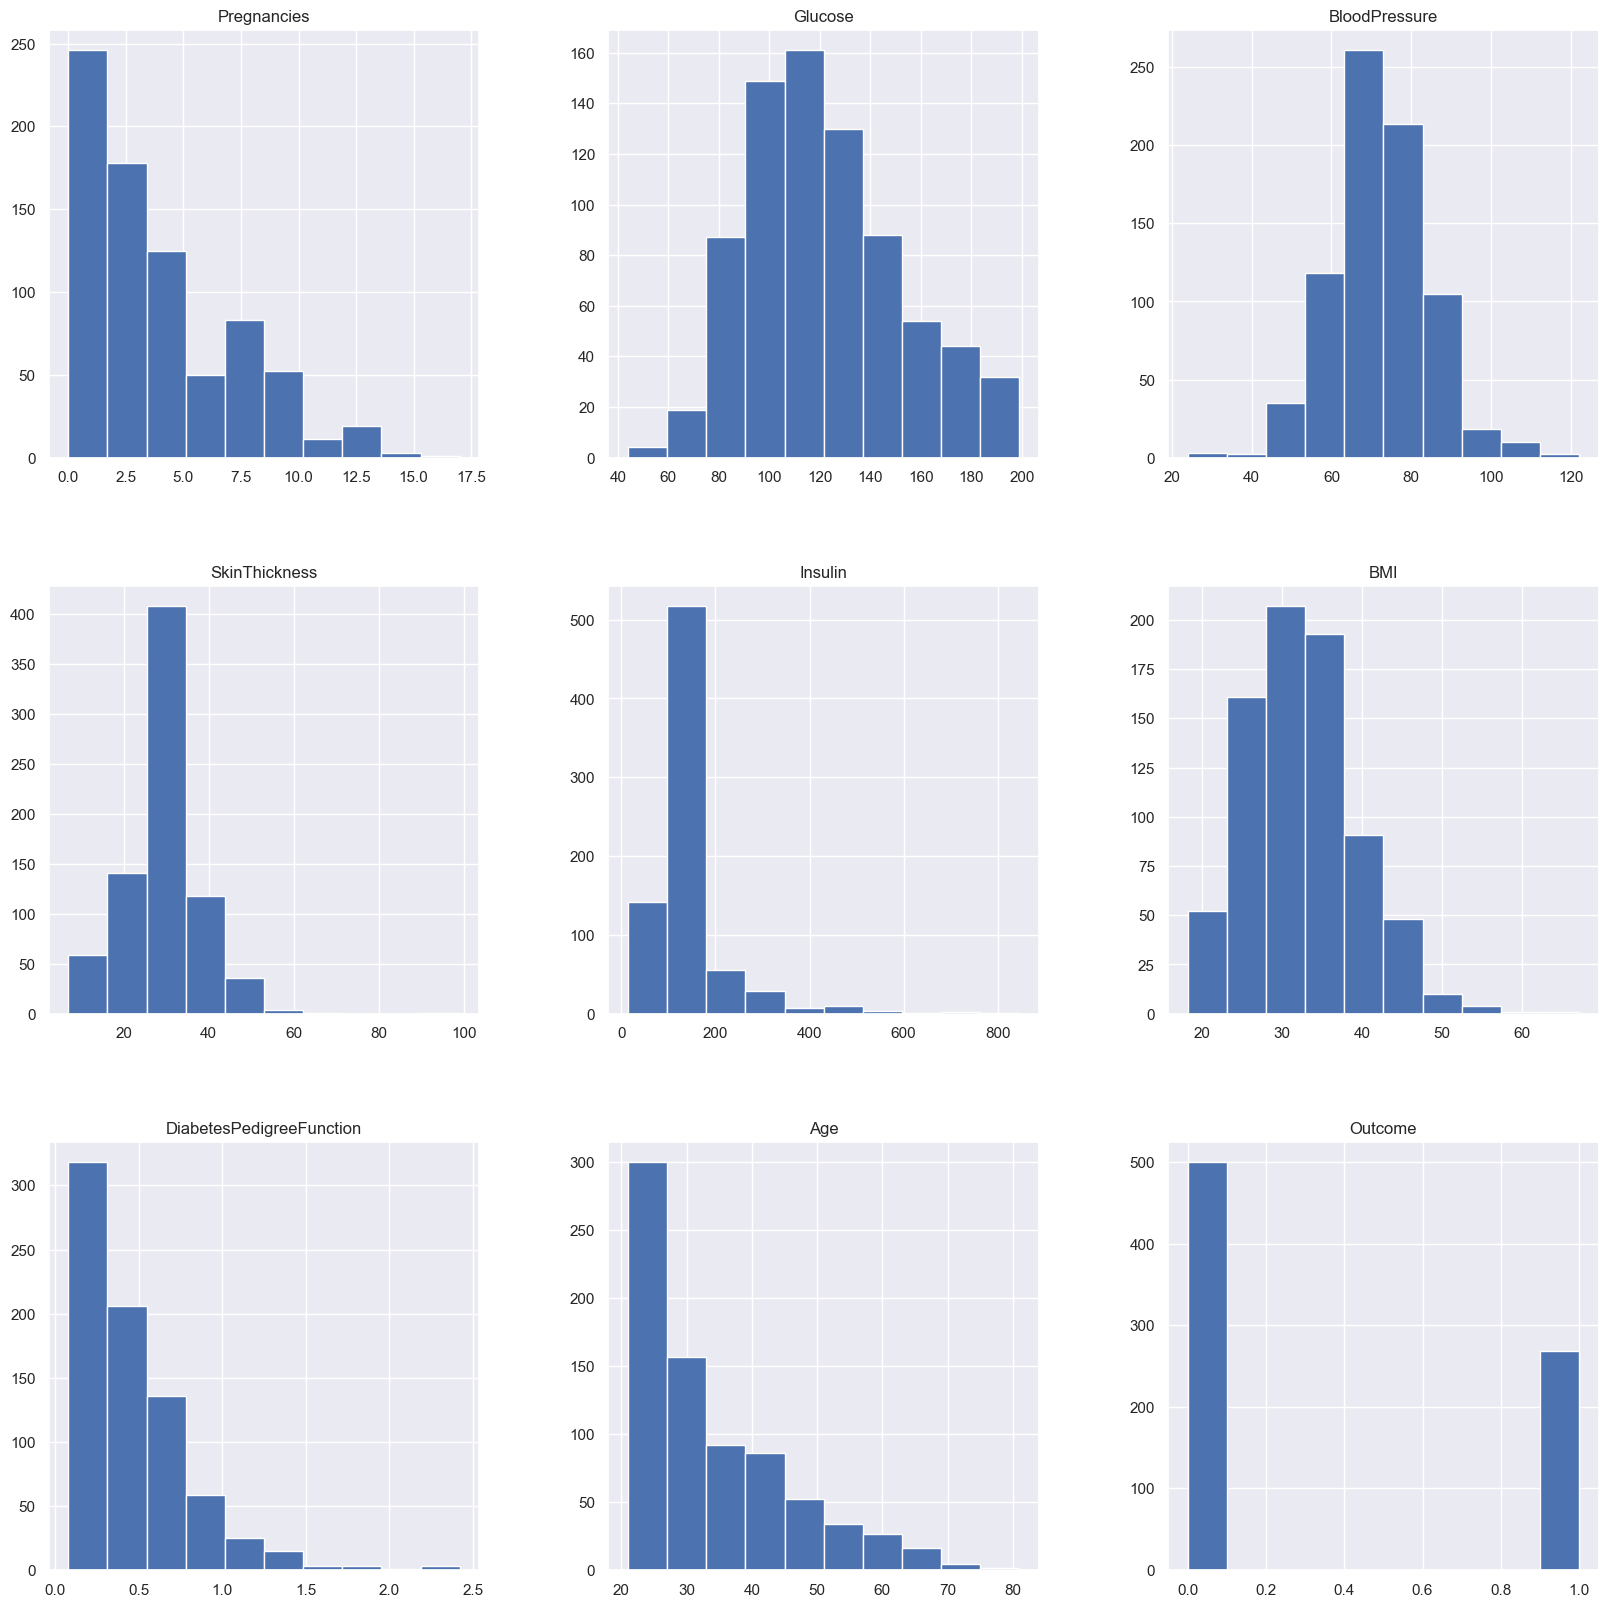

In [10]:
p = diabetes_data_copy.hist(figsize = (20,20))

In [11]:
## observing the shape of the data
diabetes_data.shape

(768, 9)

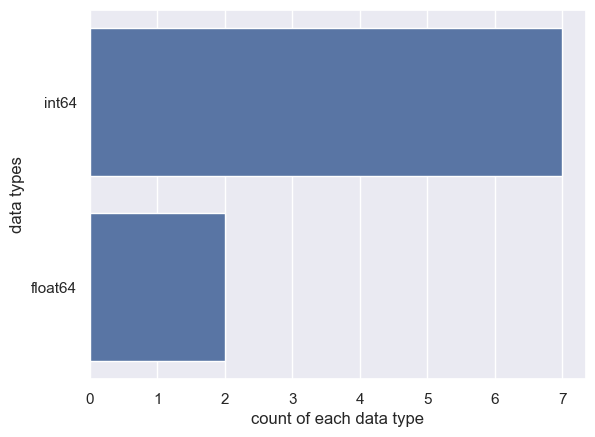

In [12]:
## data type analysis
#plt.figure(figsize=(5,5))
#sns.set(font_scale=2)
sns.countplot(y=diabetes_data.dtypes ,data=diabetes_data)
plt.xlabel("count of each data type")
plt.ylabel("data types")
plt.show()

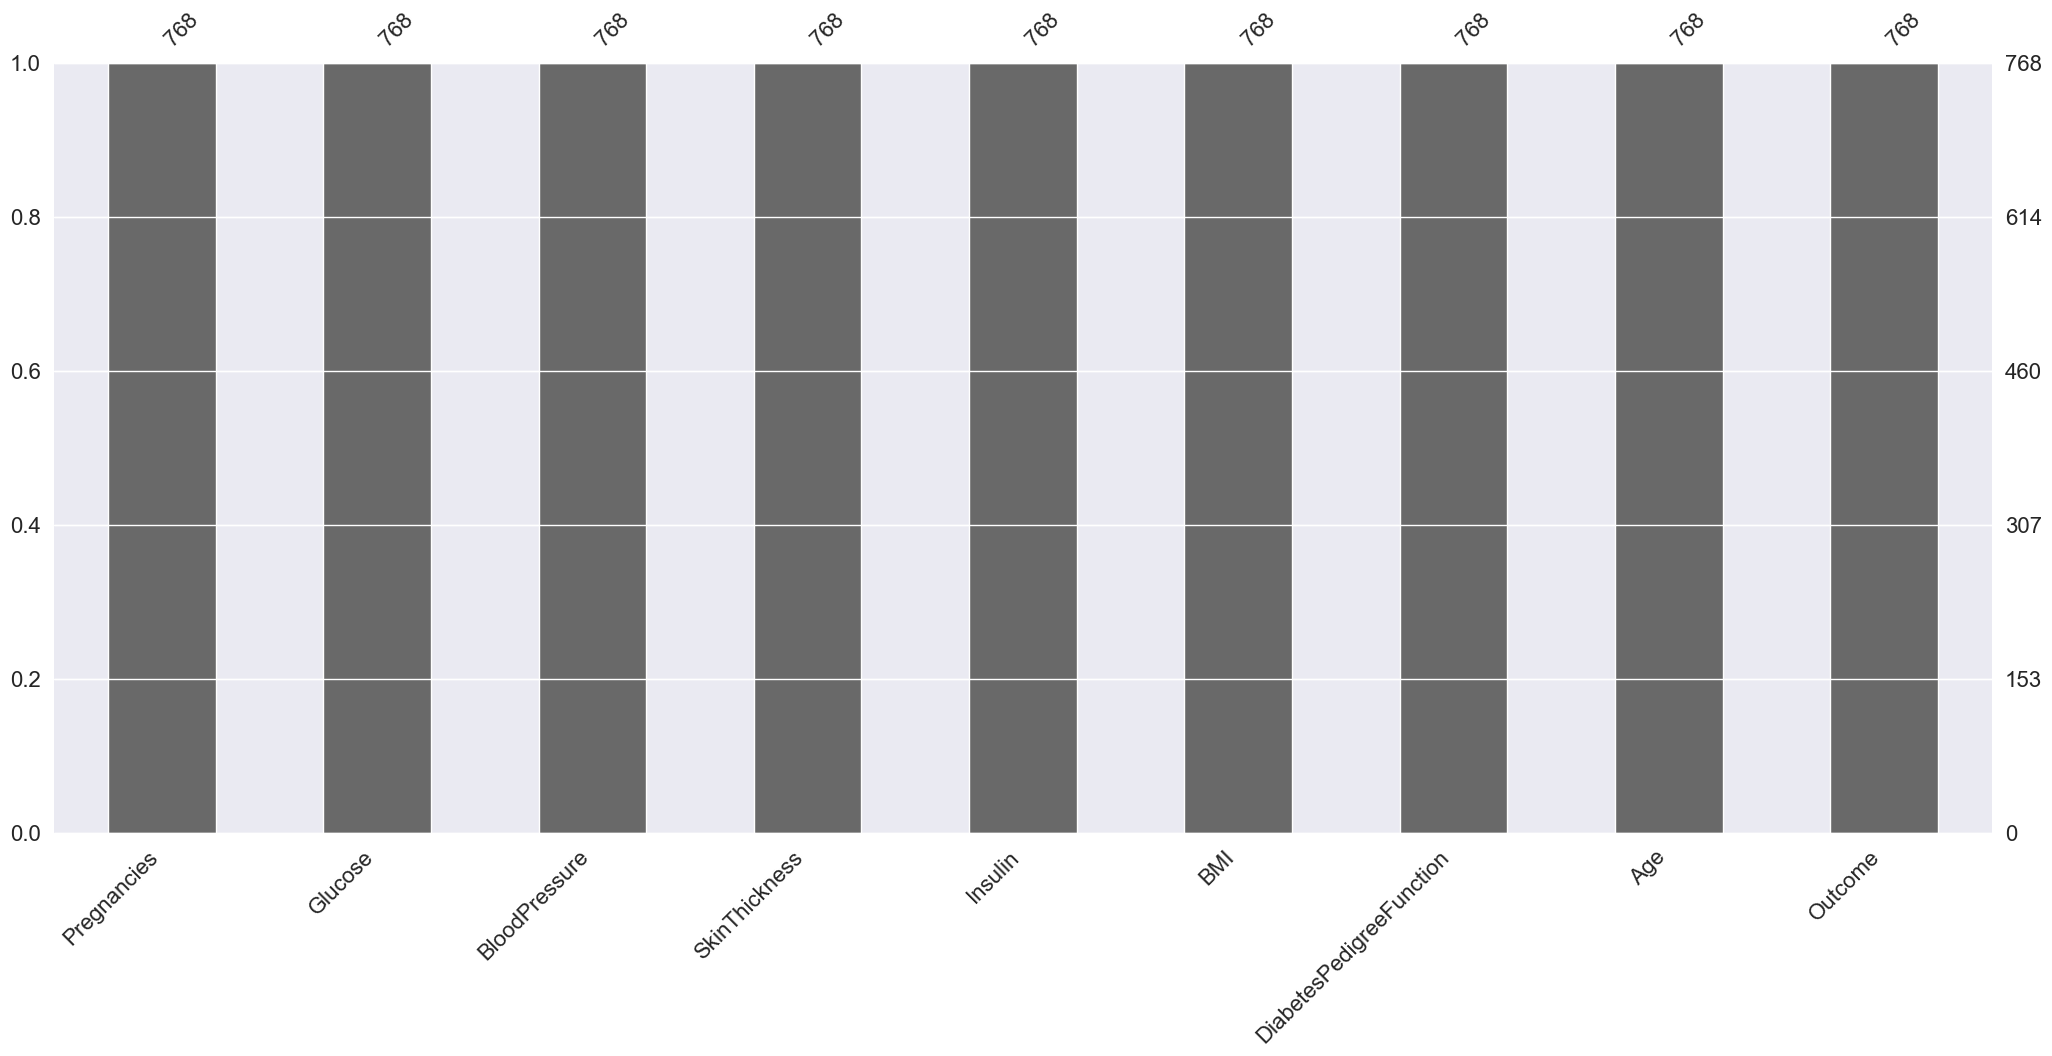

In [14]:
import missingno as msno
import matplotlib.pyplot as plt
msno.bar(diabetes_data)
plt.show()

Outcome
0    500
1    268
Name: count, dtype: int64


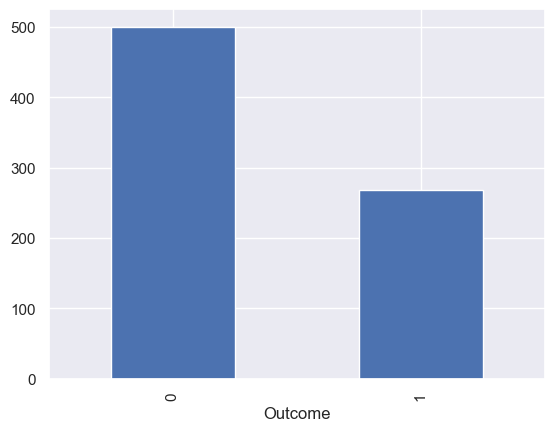

In [15]:
color_wheel = {1: "#0392cf",
 2: "#7bc043"}
colors = diabetes_data["Outcome"].map(lambda x: color_wheel.get(x + 1))
print(diabetes_data.Outcome.value_counts())
p=diabetes_data.Outcome.value_counts().plot(kind="bar")

Outcome
0    500
1    268
Name: count, dtype: int64


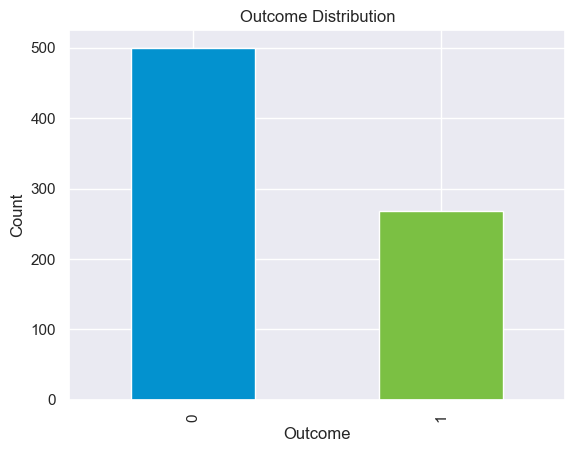

In [16]:
import matplotlib.pyplot as plt
# Count values
print(diabetes_data["Outcome"].value_counts())
# Plot with colors
color_wheel = {1: "#0392cf", 2: "#7bc043"}
colors = diabetes_data["Outcome"].map(lambda x: color_wheel.get(x + 1))
diabetes_data["Outcome"].value_counts().plot(
 kind="bar",
 color=["#0392cf", "#7bc043"] # directly assign colors
)
plt.xlabel("Outcome")
plt.ylabel("Count")
plt.title("Outcome Distribution")
plt.show()

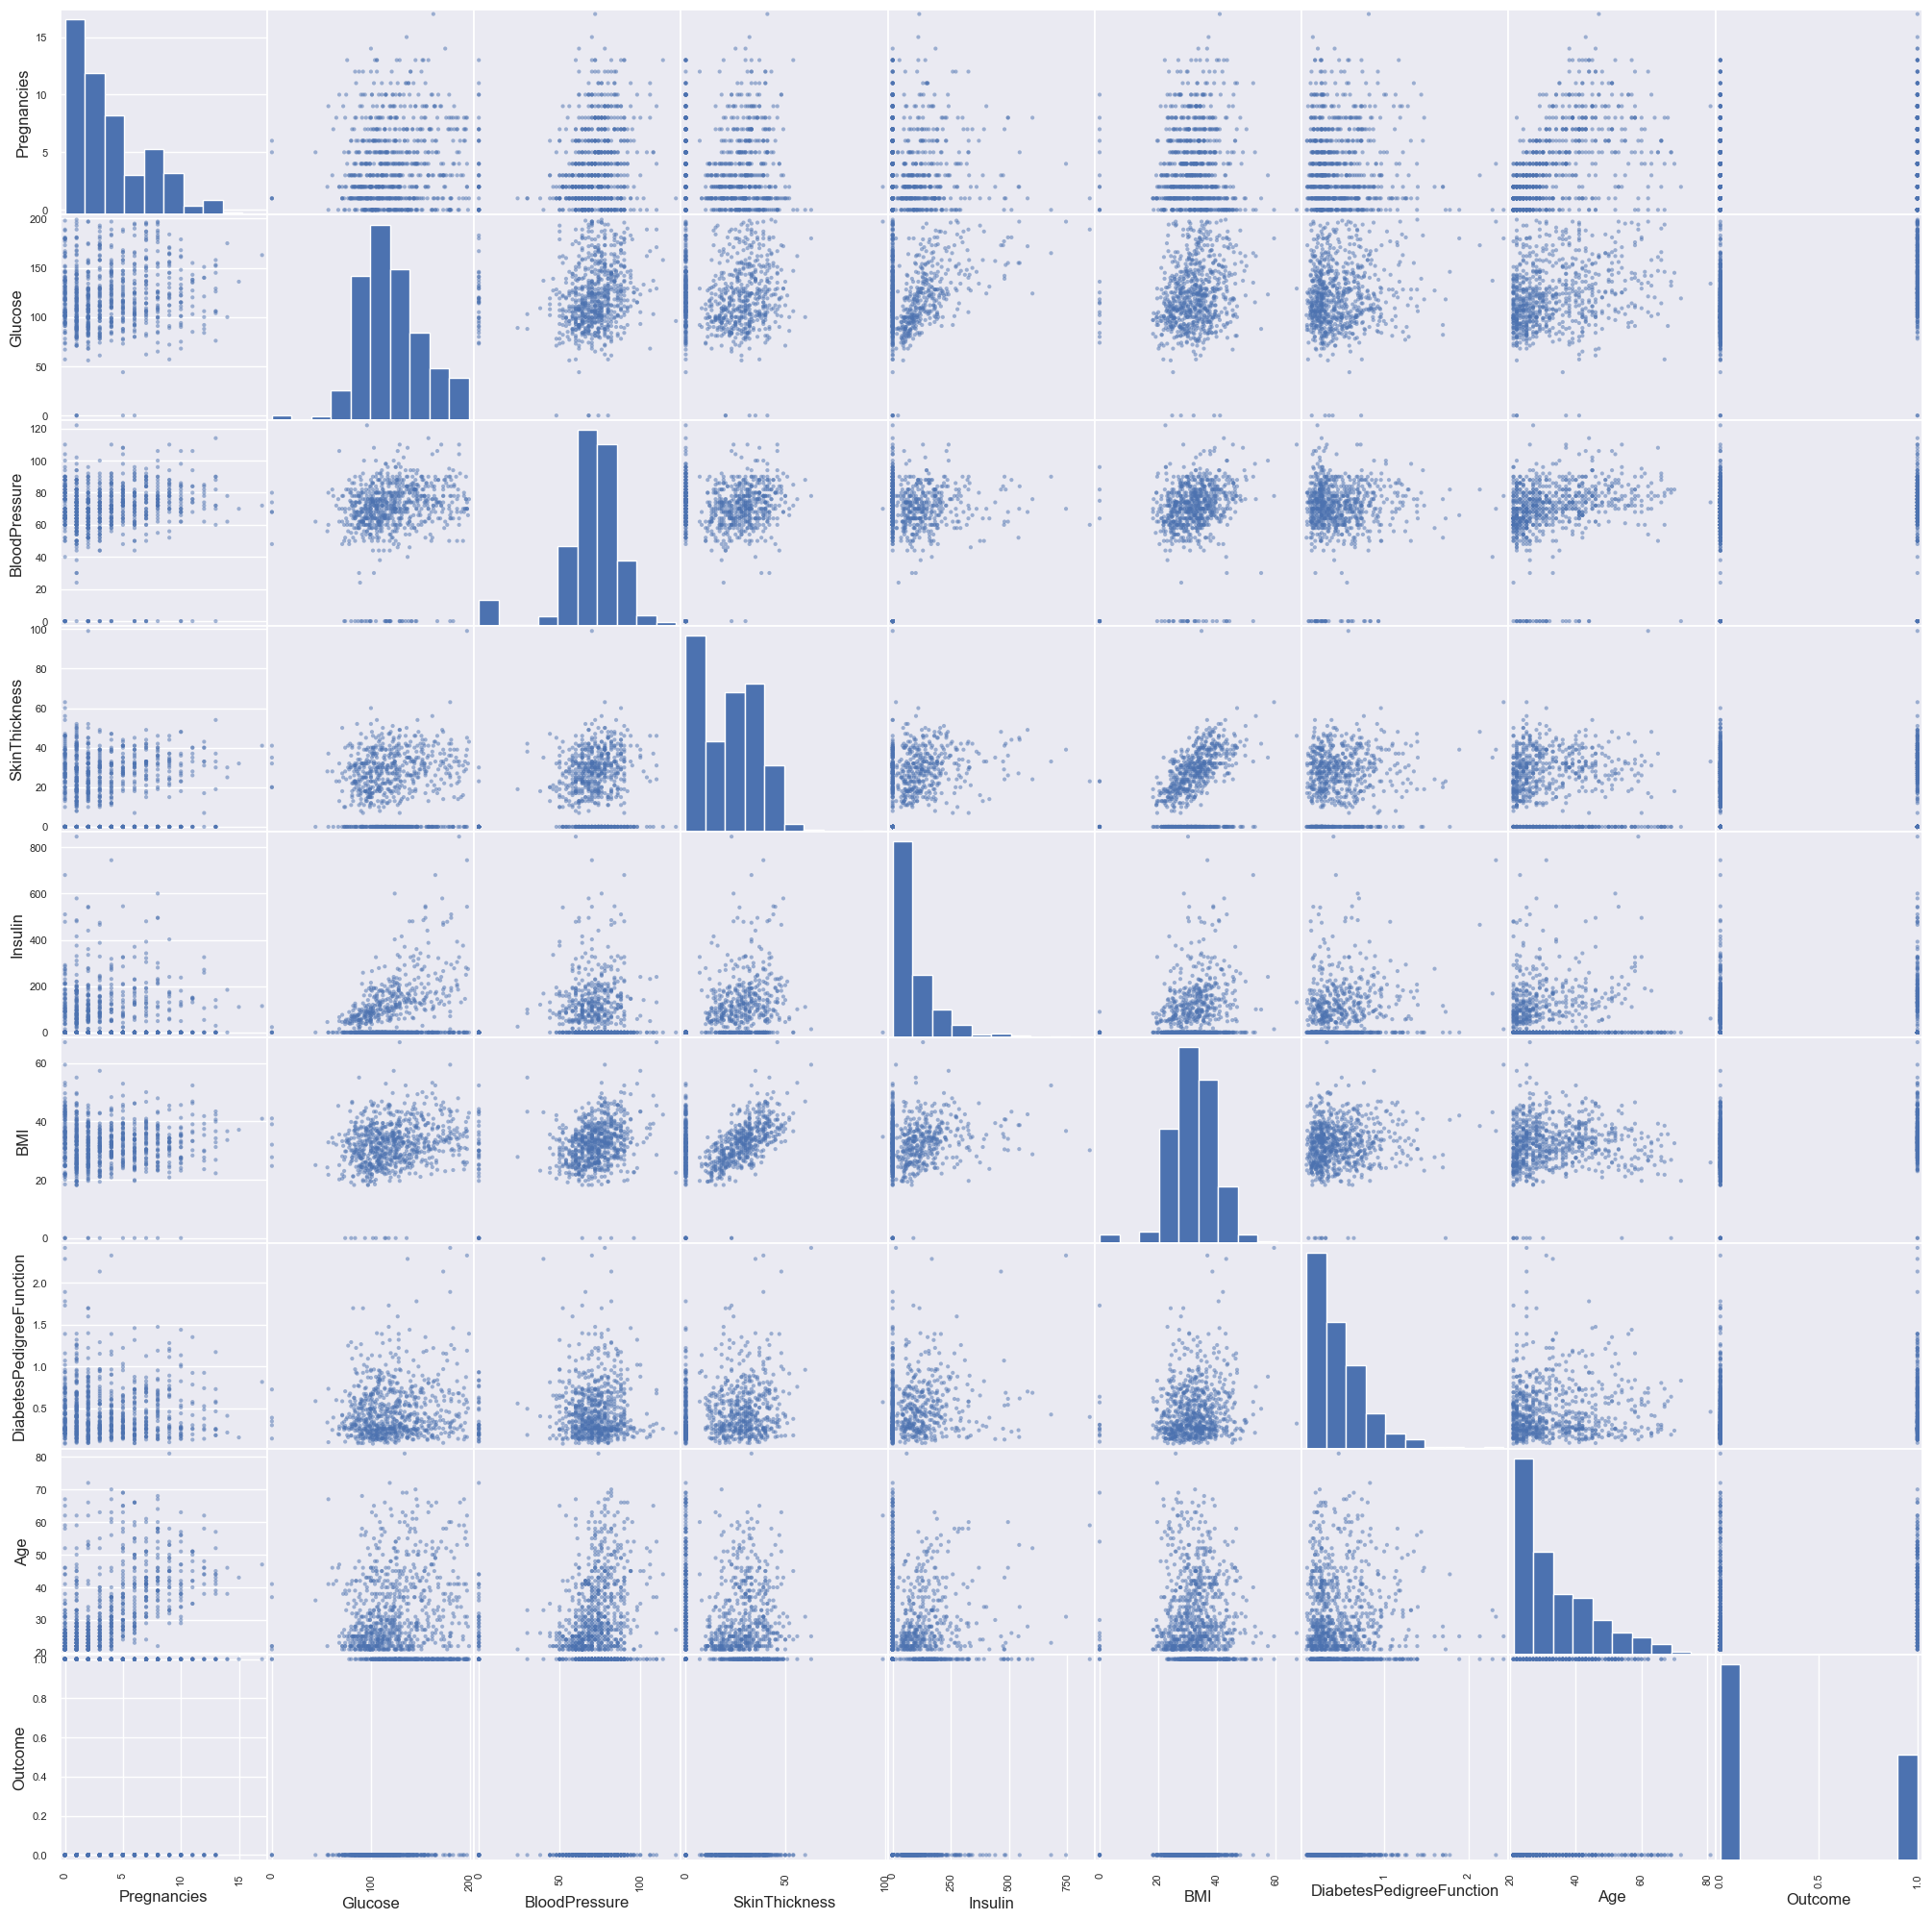

In [17]:
from pandas.plotting import scatter_matrix
import matplotlib.pyplot as plt
p = scatter_matrix(diabetes_data, figsize=(25, 25))
plt.show()

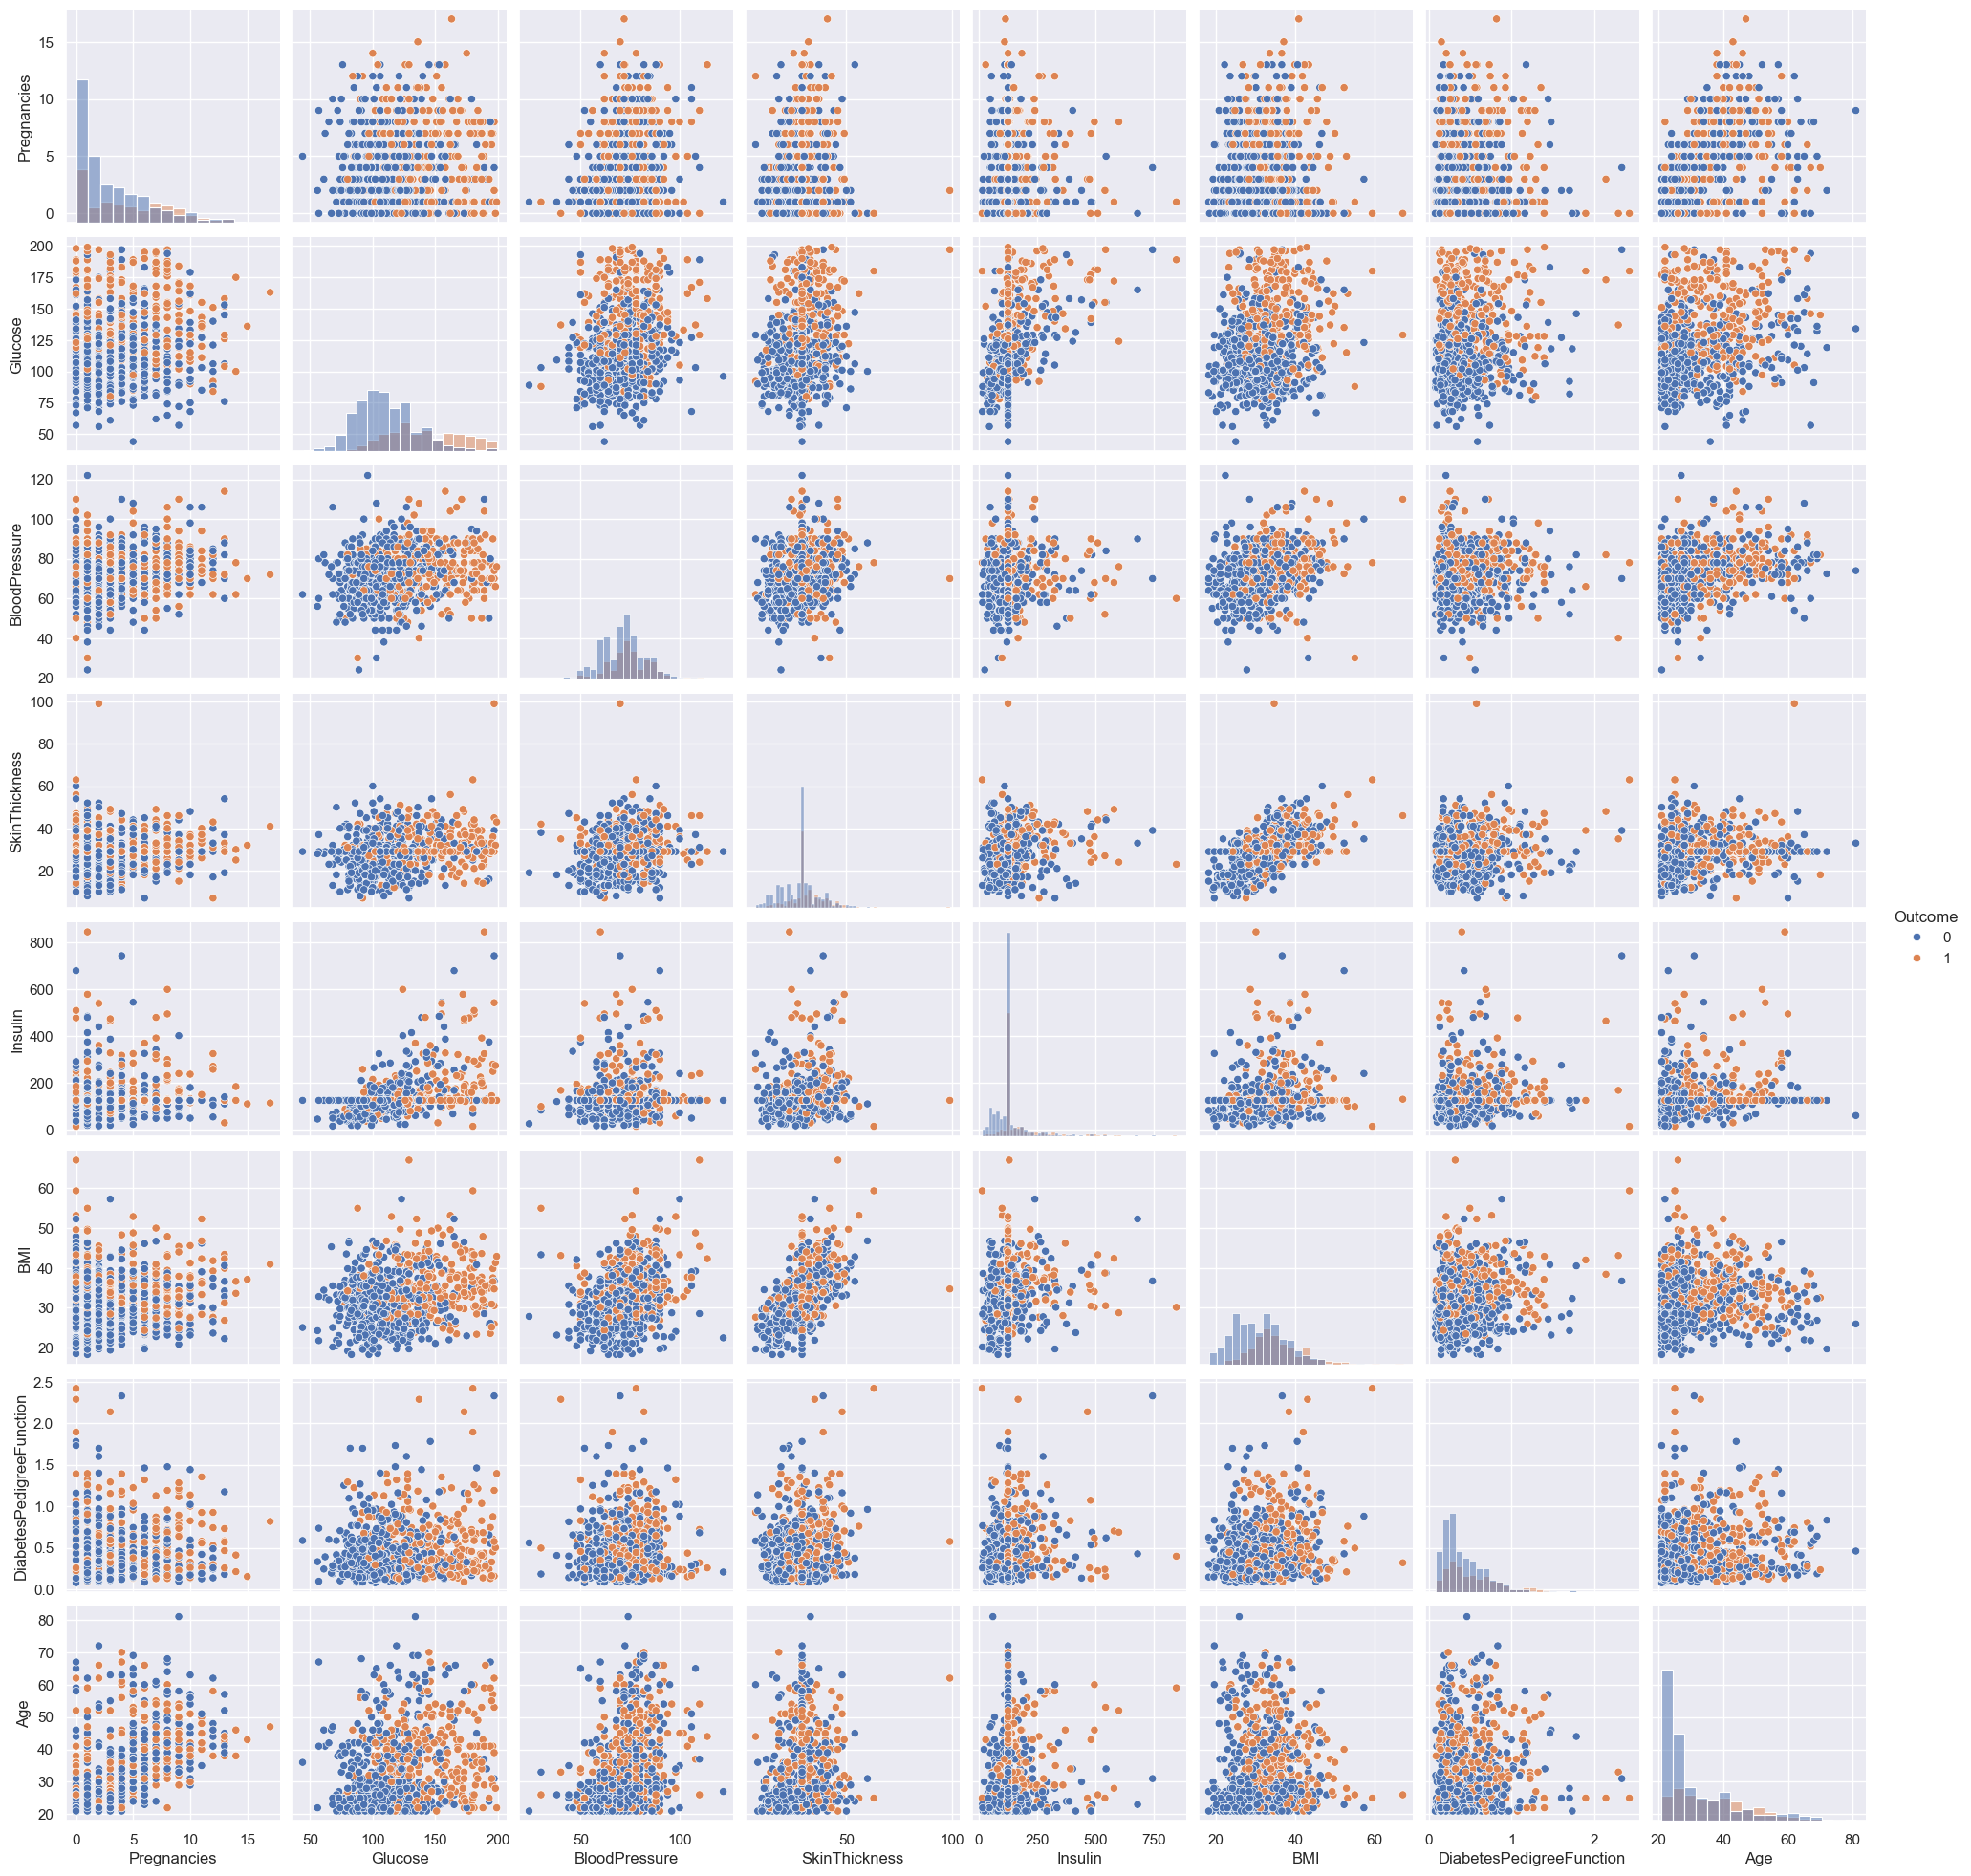

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt
# Pairplot with Outcome as hue
p = sns.pairplot(diabetes_data_copy, hue="Outcome", diag_kind="hist")
plt.show()

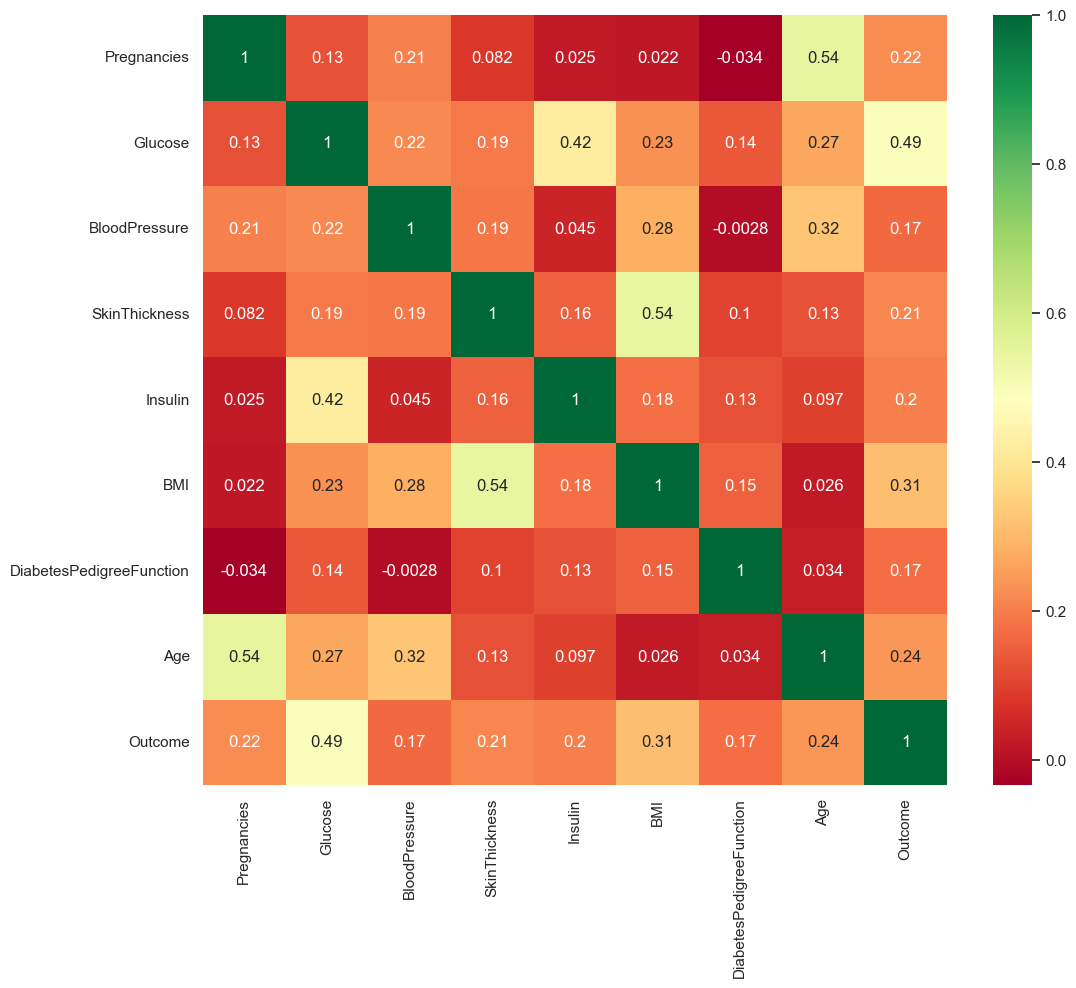

In [19]:
plt.figure(figsize=(12,10)) # on this line I just set the size of figure
p=sns.heatmap(diabetes_data_copy.corr(), annot=True,cmap ='RdYlGn') # se
plt.show()

In [20]:
from sklearn.preprocessing import StandardScaler
feature_cols = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 
                'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']

# Initialize the scaler
sc_X = StandardScaler()

# Fit and transform the features, then create a DataFrame
X = pd.DataFrame(sc_X.fit_transform(diabetes_data_copy[feature_cols]), columns=feature_cols)

# Target variable
y = diabetes_data_copy['Outcome']

In [21]:
X.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,0.639947,0.865108,-0.033518,0.670643,-0.181541,0.166619,0.468492,1.425995
1,-0.844885,-1.206162,-0.529859,-0.012301,-0.181541,-0.852200,-0.365061,-0.190672
2,1.233880,2.015813,-0.695306,-0.012301,-0.181541,-1.332500,0.604397,-0.105584
3,-0.844885,-1.074652,-0.529859,-0.695245,-0.540642,-0.633881,-0.920763,-1.041549
4,-1.141852,0.503458,-2.680669,0.670643,0.316566,1.549303,5.484909,-0.020496


In [22]:
#X = diabetes_data.drop("Outcome",axis = 1)
y = diabetes_data_copy.Outcome

In [23]:
# Importing train_test_split
from sklearn.model_selection import train_test_split

# Splitting dataset into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=1/3, 
                                                    random_state=42)

In [24]:
from sklearn.neighbors import KNeighborsClassifier
test_scores = []
train_scores = []
for i in range(1,15):
 knn = KNeighborsClassifier(i)
 knn.fit(X_train,y_train)

 train_scores.append(knn.score(X_train,y_train))
 test_scores.append(knn.score(X_test,y_test))

In [26]:
max_train_score = max(train_scores)

# Find the index of max score (assuming index 0 corresponds to k=1)
train_scores_ind = [i + 1 for i, v in enumerate(train_scores) if v == max_train_score]

print('Max train score {} % and k = {}'.format(max_train_score*100, train_scores_ind))

Max train score 100.0 % and k = [1]


In [31]:
max_test_score = max(test_scores)

# Find index (indices) of maximum test score
test_scores_ind = [i + 1 for i, v in enumerate(test_scores) if v == max_test_score]

# Print result
print('Max test score {} % and k = {}'.format(max_test_score*100, test_scores_ind))

Max test score 73.4375 % and k = [8]


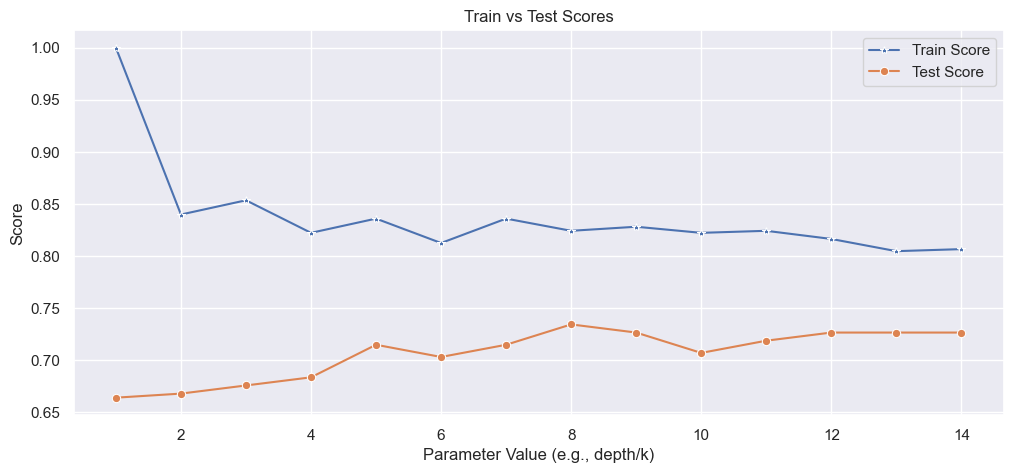

In [33]:
plt.figure(figsize=(12,5))

# Plot train scores
sns.lineplot(x=range(1,15), y=train_scores, marker='*', label='Train Score')

# Plot test scores
sns.lineplot(x=range(1,15), y=test_scores, marker='o', label='Test Score')

plt.xlabel("Parameter Value (e.g., depth/k)")
plt.ylabel("Score")
plt.title("Train vs Test Scores")
plt.legend()
plt.show()

In [34]:
#Setup a knn classifier with k neighbors
knn = KNeighborsClassifier(11)
knn.fit(X_train,y_train)
knn.score(X_test,y_test)

0.71875

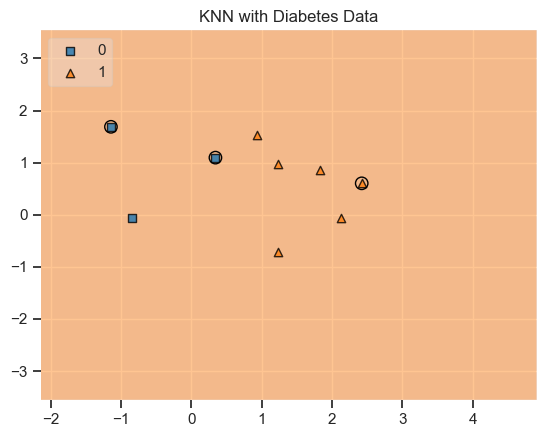

In [36]:
from mlxtend.plotting import plot_decision_regions
import matplotlib.pyplot as plt

# Example filler values and ranges for features beyond the first two
value = 20000
width = 20000

plot_decision_regions(
    X.values, 
    y.values, 
    clf=knn, 
    legend=2,
    filler_feature_values={2: value, 3: value, 4: value, 5: value, 6: value, 7: value},
    filler_feature_ranges={2: width, 3: width, 4: width, 5: width, 6: width, 7: width},
    X_highlight=X_test.values
)

plt.title('KNN with Diabetes Data')
plt.show()


In [38]:
# Import confusion_matrix
from sklearn.metrics import confusion_matrix
import pandas as pd
# Get predictions using the trained classifier
y_pred = knn.predict(X_test)
ct = pd.crosstab(y_test, y_pred, rownames=['True'], colnames=['Predicted'], margins=True)
print(ct)

Predicted    0   1  All
True                   
0          134  36  170
1           36  50   86
All        170  86  256


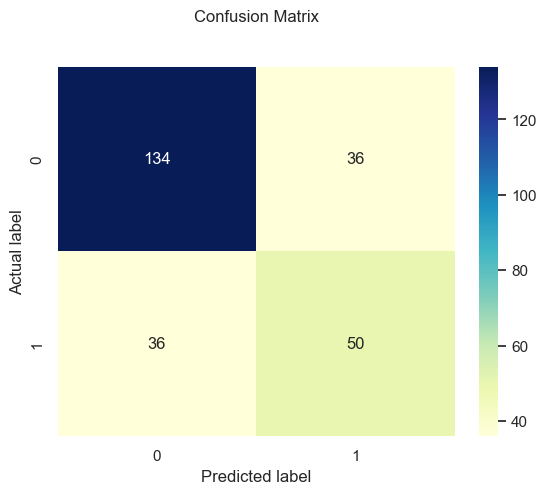

In [39]:
y_pred = knn.predict(X_test)
from sklearn import metrics
cnf_matrix = metrics.confusion_matrix(y_test, y_pred)
p = sns.heatmap(pd.DataFrame(cnf_matrix), annot=True, cmap="YlGnBu", fmt='g')

plt.title('Confusion Matrix', y=1.1)
plt.ylabel('Actual label')
plt.xlabel('Predicted label')
plt.show()

In [40]:
#import classification_report
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.79      0.79      0.79       170
           1       0.58      0.58      0.58        86

    accuracy                           0.72       256
   macro avg       0.68      0.68      0.68       256
weighted avg       0.72      0.72      0.72       256



In [41]:
from sklearn.metrics import roc_curve
y_pred_proba = knn.predict_proba(X_test)[:,1]
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

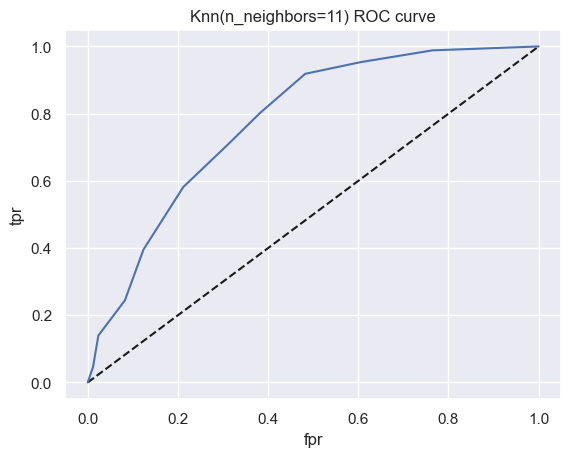

In [42]:
plt.plot([0,1],[0,1],'k--')
plt.plot(fpr,tpr, label='Knn')
plt.xlabel('fpr')
plt.ylabel('tpr')
plt.title('Knn(n_neighbors=11) ROC curve')
plt.show()

In [43]:
#Area under ROC curve
from sklearn.metrics import roc_auc_score
roc_auc_score(y_test,y_pred_proba)

0.7766073871409028

In [44]:
#import GridSearchCV
from sklearn.model_selection import GridSearchCV
#In case of classifier like knn the parameter to be tuned is n_neighbors
param_grid = {'n_neighbors':np.arange(1,50)}
knn = KNeighborsClassifier()
knn_cv= GridSearchCV(knn,param_grid,cv=5)
knn_cv.fit(X,y)
print("Best Score:" + str(knn_cv.best_score_))
print("Best Parameters: " + str(knn_cv.best_params_))

Best Score:0.7721840251252015
Best Parameters: {'n_neighbors': np.int64(25)}
